## Flowchart graph creation
This script creates graphs for manuscript/images/patx_methodology.svg

### Minimalistic graph of time series from MITBIH dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import optuna
%matplotlib inline

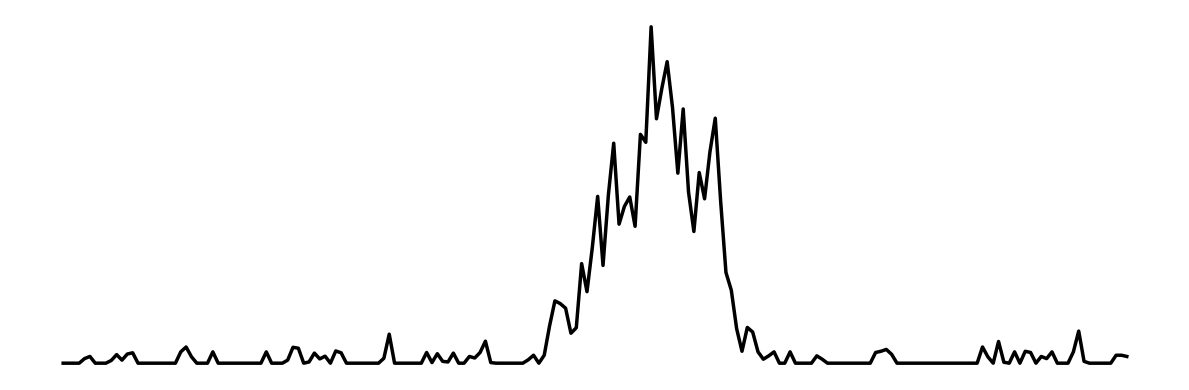

In [2]:
df = pd.read_parquet('../processed_datasets/remc/E003.parquet')
feature_cols = [col for col in df.columns if col.startswith('H3K4me3_')]
feature_cols.sort(key=lambda x: int(x.split('_')[1]))
time_series = df[feature_cols].iloc[0].values

x = np.arange(len(time_series))
plt.figure(figsize=(12, 4))
plt.plot(x, time_series, 'k-', linewidth=2.5, label='Time Series')
plt.axis('off')
plt.tight_layout()
plt.savefig('../manuscript/images/flowchart/flowchart_difference.svg', dpi=300, bbox_inches='tight', pad_inches=0.05, transparent=True)
plt.show()

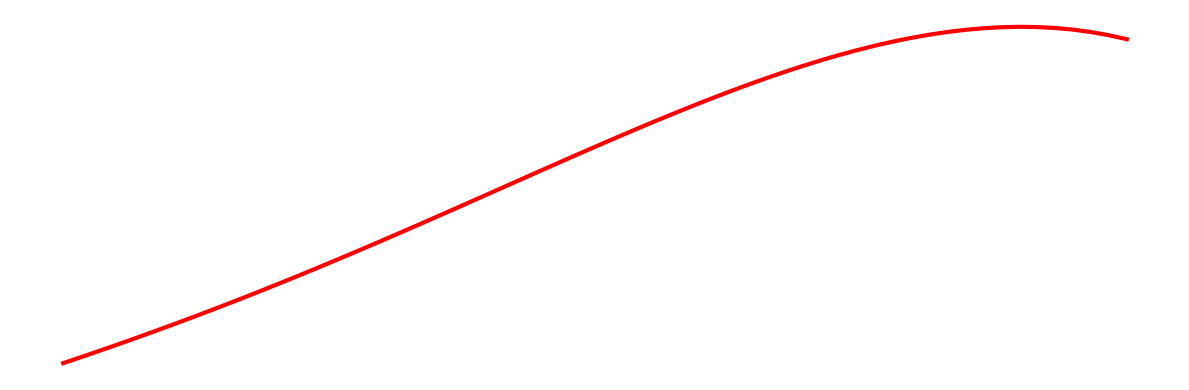

In [3]:
start = 70
width = 60
def optimize_pattern(ts, start, width, degree=3, n_trials=200):
    segment = ts[start:start+width]
    
    def objective(trial):
        coeffs = [trial.suggest_float(f'c{i}', -10, 10) for i in range(degree + 1)]
        pattern_x = np.linspace(0, 1, width)
        pattern = np.polyval(coeffs, pattern_x)
        return np.mean((segment - pattern)**2)
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    return np.array([study.best_params[f'c{i}'] for i in range(degree + 1)])
coeffs = optimize_pattern(time_series, start, width, degree=4)
pattern_x = np.linspace(0, 1, width)
pattern = np.polyval(coeffs, pattern_x)

plt.figure(figsize=(12, 4))
plt.plot(pattern, 'r-', linewidth=3)
plt.axis('off')
plt.tight_layout()
plt.savefig('../manuscript/images/flowchart/flowchart_pattern.svg', dpi=300, bbox_inches='tight', pad_inches=0.05, transparent=True)
plt.show()

Time series length: 200
Pattern length: 60
x_pattern length: 60
Start: 70, End: 130, Width: 60


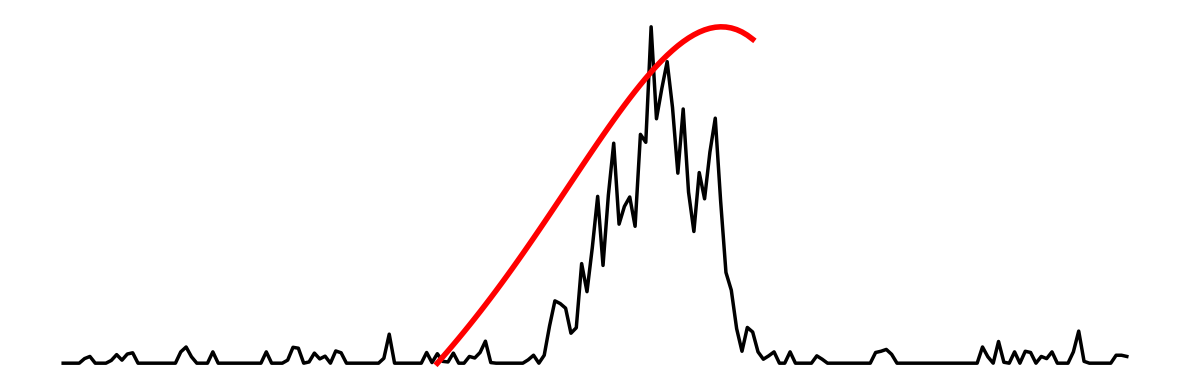

In [4]:
end = start + width
ts_segment = time_series[start:end]
pattern_scaled = (pattern - pattern.min()) / (pattern.max() - pattern.min())
pattern_scaled = pattern_scaled * (ts_segment.max() - ts_segment.min()) + ts_segment.min()

x_pattern = np.arange(start, end)
print(f"Time series length: {len(x)}")
print(f"Pattern length: {len(pattern_scaled)}")
print(f"x_pattern length: {len(x_pattern)}")
print(f"Start: {start}, End: {end}, Width: {width}")

plt.figure(figsize=(12, 4))
plt.plot(x, time_series, 'k-', linewidth=2.5, label='Time Series')
plt.plot(x_pattern, pattern_scaled, 'r-', linewidth=4, label='Pattern')
plt.axis('off')
plt.tight_layout()
plt.savefig('../manuscript/images/flowchart/flowchart_difference.svg', dpi=300, bbox_inches='tight', pad_inches=0.05, transparent=True)
plt.show()

### Mathematical transform example: FFT Power
Demonstrating how raw time series data is transformed into frequency domain for pattern matching.

In [ ]:
from scipy import fft

def fft_power_transform(data):
    """Apply FFT power transformation to time series data."""
    fft_values = fft.fft(data)
    power = np.abs(fft_values) ** 2
    return power[:len(power) // 2]

# Transform the time series segment to frequency domain
segment = time_series[start:end]
frequencies = np.fft.fftfreq(len(segment))
fft_power = fft_power_transform(segment)
positive_freq = frequencies[:len(segment)//2]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Left: Original time series
ax1.plot(segment, 'k-', linewidth=2.5)
ax1.set_title('Time Domain', fontsize=12, pad=10)
ax1.axis('off')

# Right: FFT power spectrum
ax2.plot(positive_freq, fft_power, 'r-', linewidth=2.5)
ax2.set_title('Frequency Domain (FFT Power)', fontsize=12, pad=10)
ax2.axis('off')

plt.tight_layout()
plt.savefig('../manuscript/images/flowchart/fft_transform.svg', dpi=300, bbox_inches='tight', pad_inches=0.05, transparent=True)
plt.show()

### Bayesian optimization visualization


|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8197722 | 3.1086569 |
| 2         | 0.2118028 | 9.9999674 |
| 3         | 0.8192940 | 3.1097143 |
| 4         | 1.0069395 | 0.3176592 |
| 5         | 0.2016616 | -2.0      |
| 6         | 1.2713998 | 1.5894281 |


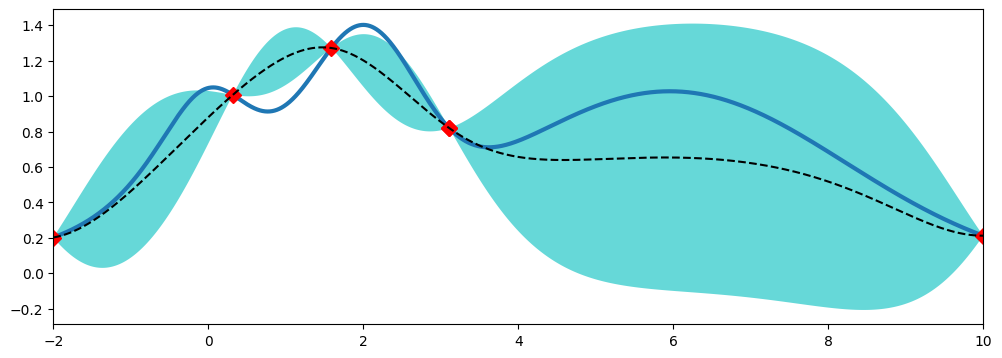

In [5]:
#!pip install bayesian-optimization
# from https://github.com/bayesian-optimization/BayesianOptimization/blob/master/examples/visualization.ipynb
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
from matplotlib import gridspec

def target(x):
    return np.exp(-(x - 2)**2) + np.exp(-(x - 6)**2/10) + 1/ (x**2 + 1)

x = np.linspace(-2, 10, 10000).reshape(-1, 1)
y = target(x)
acquisition_function = acquisition.UpperConfidenceBound(kappa=5.)
optimizer = BayesianOptimization(target, {'x': (-2, 10)}, acquisition_function=acquisition_function, random_state=27)
optimizer.maximize(init_points=0, n_iter=5)

def posterior(optimizer, grid):
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma

def plot_gp(optimizer, x, y):
    fig = plt.figure(figsize=(12, 6))
    
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1]) 
    axis = plt.subplot(gs[0])
    
    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])
    
    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label='Target')
    axis.plot(x_obs.flatten(), y_obs, 'D', markersize=8, label=u'Observations', color='r')
    axis.plot(x, mu, '--', color='k', label='Prediction')

    axis.fill(np.concatenate([x, x[::-1]]), 
              np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=.6, fc='c', ec='None', label='95% confidence interval')
    
    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    plt.savefig('../manuscript/images/flowchart/bayesian_optimization.svg', dpi=300, bbox_inches='tight', pad_inches=0.05, transparent=True)

plot_gp(optimizer, x, y)

## Visualizing patterns after pattern extraction

In [8]:
import numpy as np
from patx import PatternExtractor, load_remc_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load the included REMC dataset with two time series (H3K4me3, H3K4me1)
data = load_remc_data(series=("H3K4me3", "H3K4me1"))
X_list = data['X_list']  # list of np arrays, one per series
y = data['y']
series_names = data['series_names']

print(f"Loaded {len(X_list)} series: {series_names}")
print(f"Samples: {len(y)}, time points per series: {X_list[0].shape[1]}")  # 40 time points (binned for lightweight package)

# Split indices, then slice each series list (multiple time series)
indices = np.arange(len(y))
train_indices, test_indices = train_test_split(
    indices, test_size=0.3, random_state=42, stratify=y
)

X_train_list = [X[train_indices] for X in X_list]
X_test_list = [X[test_indices] for X in X_list]
y_train, y_test = y[train_indices], y[test_indices]

# Create PatternExtractor (automatically detects multiple series)
optimizer = PatternExtractor(
    X_train=X_train_list,
    y_train=y_train,
    X_test=X_test_list,
    max_n_trials=100,
    show_progress=False
)

# Extract features and train model
result = optimizer.feature_extraction()

# Get results
trained_model = result['model']
patterns = result['patterns']
test_probabilities = trained_model.predict_proba_positive(result['X_test'])

# Evaluate performance
auc_score = roc_auc_score(y_test, test_probabilities)
print(f"\nResults:")
print(f"Discovered {len(patterns)} patterns across {len(X_list)} time series")
print(f"Test AUC: {auc_score:.4f}")

Loaded 2 series: ['H3K4me3', 'H3K4me1']
Samples: 1841, time points per series: 40

Results:
Discovered 7 patterns across 2 time series
Test AUC: 0.8872


## Custom visualize_patterns implementation


In [9]:
import os
import seaborn as sns

def calculate_pattern_rmse(X_region, pattern_values):
    return np.sqrt(np.mean((X_region - pattern_values) ** 2, axis=1))

pattern_list = optimizer.pattern_list
pattern_starts = optimizer.pattern_starts
pattern_ends = optimizer.pattern_ends
pattern_series_indices = optimizer.pattern_series_indices

valid_indices = [0]
n_patterns = len(valid_indices)
colors = {'pattern': 'blue', 'active': 'red'}
n_rows = 2
n_cols = 1
figsize = (10, 6)

fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

pattern_idx = valid_indices[0]
pattern = pattern_list[pattern_idx]
start = pattern_starts[pattern_idx]
end = pattern_ends[pattern_idx]

ax_top = axes[0]
active_x = range(start, end)

ax_top.plot(range(len(pattern)), pattern, color=colors['pattern'], alpha=0.3)
ax_top.plot(active_x, pattern[start:end], color=colors['active'], linewidth=3)
ax_top.scatter(active_x, pattern[start:end], c=colors['active'], s=50, zorder=5)

ax_top.set_xlabel('Position in time series', fontsize=14)
ax_top.set_ylabel('Pattern Y-value', fontsize=14)
ax_top.tick_params(labelbottom=False, labelleft=False)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)

ax_bottom = axes[1]
series_idx = pattern_series_indices[pattern_idx]
X_data = X_train_list[series_idx] 
X_region = X_data[:, start:end]
rmse_values = calculate_pattern_rmse(X_region, pattern[start:end].astype(np.float32)).flatten()

sns.histplot(x=rmse_values, hue=y_train, bins=100, alpha=0.7, ax=ax_bottom)
ax_bottom.set_xlabel('Pattern similarity (RMSE)', fontsize=14)
ax_bottom.set_ylabel('Count', fontsize=14)
ax_bottom.tick_params(labelbottom=False, labelleft=False)
ax_bottom.spines['top'].set_visible(False)
ax_bottom.spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('../manuscript/images', exist_ok=True)
plt.savefig('../manuscript/images/patterns_analysis.svg', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


/var/folders/tp/s93g_ywj25q87c9hgdw53dtm0000gn/T/ipykernel_64418/1710780652.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Test custom visualization with extracted patterns
